In [2]:
import os
import sys
sys.path.append(os.path.join('/simulation', 'code'))

import numpy as np
import pandas as pd

import pandapower
import re

from lxml import etree

from meslf.networks.gas_network import GasNetwork, GasNode, GasLink, GasHalfLink
from meslf.networks.carrier import Gas
from meslf.networks.electrical_network import ElectricalNetwork, ElectricalNode, ElectricalLink, ElectricalHalfLink
from meslf.networks.heterogeneous_network import HeterogeneousNetwork, HeterogeneousNode
from meslf.utils.constants import bar, mbar, kV, MW

from meslf.networks.gaslib_network import *

In [ ]:
def get_data(network_name):
    """
    Get data from pandapower based on the name of the network.

    Parameters
    ----------
        network_name : str
            Name of the network. Options:
                case4gs
                case5
                case6ww
                case9
                case14
                case24_ieee_rts
                case30
                case_ieee30
                case33bw
                case39
                case57
                case89pegase
                case118
                case145
                case_illinois200
                case300
                case1354pegase
                case1888rte
                case2848rte
                case2869pegase
                case3120sp
                case6470rte
                case6495rte
                case6515rte
                case9241pegase
                GBnetwork
                GBreducednetwork
                iceland

    Return
    ----------
        Return : pandapower.networks
            A pandapower network object
    """
    
    result = {}
    exec("data = pandapower.networks.{}()".format(network_name),
         globals(),
         result)
    return result["data"]

def find_node(name, network, node_names):
    return network.nodes[node_names.index(name)]

def compute_admittance(c_nf_per_km, f, g_us_per_km, length_km, parallel, r_ohm_per_km, x_ohm_per_km, Vn, Sn):
    Zn = Vn**2 / Sn
    r = r_ohm_per_km*length_km/parallel / Zn
    x = x_ohm_per_km*length_km/parallel / Zn
    
    b = -x / (r**2 + x**2)
    g = r / (r**2 + x**2)
    
    b_sh = 2*np.pi*f*c_nf_per_km*10**-9*length_km*parallel * Zn
    g_sh = g_us_per_km*10**-6*length_km*parallel * Zn

    return b, g, b_sh, g_sh

def compute_trafo(vn_hv_kv, vn_lv_kv, vn_kv_from, vn_kv_to, pfe_kw, i0_percent, vk_percent, vkr_percent, \
                  sn_mva, sn_mva_net, \
                  tap_neutral, tap_phase_shifter, tap_pos, tap_side, tap_step_degree, tap_step_percent, \
                  shift_degree):
    
    if (tap_phase_shifter == False) and (not np.isnan(tap_step_percent)) and (not np.isnan(tap_neutral)) and (not np.isnan(tap_pos)): # (tap_side in ['lv', 'hv']):
        n_tap = abs(1 + (tap_pos - tap_neutral) * tap_step_percent * 0.01)
        if tap_side == 'hv':
            vn_hv_kv *= n_tap
        elif tap_side =='lv':
            vn_lv_kv *= n_tap
            
    ratio = (vn_hv_kv / vn_lv_kv) * (vn_kv_to / vn_kv_from) 

    sn_ratio = sn_mva_net / sn_mva
    
    vn_ratio = (vn_kv_to / vn_lv_kv)**2
    
    Zn = vn_kv_to**2 / sn_mva_net
    Zn_trafo = vn_lv_kv**2 * sn_ratio

    vk_percent *= 0.01
    vkr_percent *= 0.01
    i0_percent *= 0.01

    r = vkr_percent * sn_ratio
    x = vk_percent * sn_ratio
    x = np.sign(vk_percent) * np.sqrt(x**2 - r**2)
    
    b = -x / (r**2 + x**2) * vn_ratio
    g = r / (r**2 + x**2) * vn_ratio

    g_sh = pfe_kw / (sn_mva * 1000) 
    b_sh = i0_percent**2 - g_sh**2
    if b_sh < 0:
        b_sh = 0
    b_sh = -np.sign(i0_percent) * np.sqrt(b_sh) * vn_ratio / sn_ratio
    g_sh *= vn_ratio / sn_ratio
             
    if False: # tap_phase_shifter:        
        if not np.isnan(tap_step_degree):
            shift_degree_tp = tap_step_degree*(tap_pos - tap_neutral)
        elif not np.isnan(tap_step_percent):
            shift_degree_tp = 2*np.arcsin(0.5*tap_step_percent*10**-2)*(tap_pos - tap_neutral)
        else:
            shift_degree_tp = 0
        
        phase_shift = (shift_degree + shift_degree_tp)*np.pi/180
    else:
        phase_shift = 0

    return b, g, b_sh, g_sh, ratio, phase_shift

def create_network_pandapower(network_name, ignore_nodes=[], no_slack=False):
    data = get_data(network_name)

    f = data.f_hz # default frequency

    network = ElectricalNetwork(network_name)
    
    node_name = ''
    node_names = []

    data.gen.loc[data.gen["sn_mva"].isnull(), 'sn_mva'] = data.sn_mva
    data.load.loc[data.load["sn_mva"].isnull(), 'sn_mva'] = data.sn_mva
    data.sgen.loc[data.sgen["sn_mva"].isnull(), 'sn_mva'] = data.sn_mva

    # slack node
    if no_slack:
        first = True
        for index, row in data.ext_grid.iterrows():
            if row["in_service"]:
                node_name = data.bus.loc[row['bus'], 'name']
                if node_name not in ignore_nodes:
                    if first:
                        network.add_node(ElectricalNode(name=node_name,
                                                        P=0,
                                                        V=row["vm_pu"],
                                                        delta=row["va_degree"]*np.pi/180,
                                                        node_type=3,
                                                        Sbase=data.sn_mva, # slack has no base complex power, so I set default to default of network
                                                        Vbase=data.bus.loc[row['bus'], 'vn_kv']))
                        first = False
                    else:
                        network.add_node(ElectricalNode(name=node_name,
                                                        V=row["vm_pu"],
                                                        delta=row["va_degree"]*np.pi/180,
                                                        node_type=0,
                                                        Sbase=data.sn_mva, # slack has no base complex power, so I set default to default of network
                                                        Vbase=data.bus.loc[row['bus'], 'vn_kv']))
                    node_names.append(node_name)
    else:
        for index, row in data.ext_grid.iterrows():
            if row["in_service"]:
                node_name = data.bus.loc[row['bus'], 'name']
                if node_name not in ignore_nodes:
                    network.add_node(ElectricalNode(name=node_name,
                                                    V=row["vm_pu"],
                                                    delta=row["va_degree"]*np.pi/180,
                                                    node_type=0,
                                                    Sbase=data.sn_mva, # slack has no base complex power, so I set default to default of network
                                                    Vbase=data.bus.loc[row['bus'], 'vn_kv']))
                    node_names.append(node_name)
                else:
                    print("Slack node is not included in network. This leads to an ill-posed system.")

    # PV node (P=-P, V=V)
    for index, row in data.gen.iterrows():
        if row["in_service"]:
            node_name = data.bus.loc[row['bus'], 'name']
            if node_name not in node_names + ignore_nodes:
                network.add_node(ElectricalNode(name=node_name,
                                                P=-row["p_mw"]/row["sn_mva"],
                                                V=row["vm_pu"],
                                                node_type=1,
                                                Sbase=row['sn_mva'],
                                                Vbase=data.bus.loc[row['bus'], 'vn_kv']))      
                node_names.append(data.bus.loc[row['bus'], 'name'])
            elif node_name in node_names:
                ElectricalHalfLink('{}_pv_{}_{}'.format(node_name, -row["p_mw"], row["vm_pu"]), 
                                find_node(node_name, network, node_names),
                                bc_type=2,
                                P=-row["p_mw"]/row["sn_mva"])

    # PQ node (static generator, P=-P, Q=-Q)
    for index, row in data.sgen.iterrows():
        if row["in_service"]:
            node_name = data.bus.loc[row['bus'], 'name']
            if node_name not in node_names + ignore_nodes:
                network.add_node(ElectricalNode(name=node_name,
                                                P=-row["p_mw"]/row["sn_mva"],
                                                Q=-row["q_mvar"]/row["sn_mva"],
                                                node_type=2,
                                                Sbase=row['sn_mva'],
                                                Vbase=data.bus.loc[row['bus'], 'vn_kv']))      
                node_names.append(data.bus.loc[row['bus'], 'name'])
            elif node_name in node_names:
                ElectricalHalfLink('{}_pq_{}_{}'.format(node_name, -row["p_mw"], -row["q_mvar"]), 
                                   find_node(node_name, network, node_names),
                                   bc_type=1,
                                   P=-row["p_mw"]/row["sn_mva"],
                                   Q=-row["q_mvar"]/row["sn_mva"])

    # Load (PQ node)
    for index, row in data.load.iterrows():
        if row["in_service"]:
            node_name = data.bus.loc[row['bus'], 'name']
            if node_name not in node_names + ignore_nodes:
                network.add_node(ElectricalNode(name=node_name,
                                                P=row["p_mw"]/row["sn_mva"],
                                                Q=row["q_mvar"]/row["sn_mva"],
                                                node_type=2,
                                                Sbase=row["sn_mva"],
                                                Vbase=data.bus.loc[row['bus'], 'vn_kv']))
                node_names.append(node_name)
            elif node_name in node_names:
                ElectricalHalfLink('{}_pq_{}_{}'.format(node_name, row["p_mw"], row["q_mvar"]), 
                                   find_node(node_name, network, node_names),
                                   bc_type=1,
                                   P=row["p_mw"]/row["sn_mva"], 
                                   Q=row["q_mvar"]/row["sn_mva"])
                        
    # Junction (PQ Node, P=0, Q=0)
    for index, row in data.bus.iterrows():
        if row['name'] not in node_names + ignore_nodes:
            network.add_node(ElectricalNode(name=row['name'],
                                            P=None,
                                            Q=None,
                                            node_type=2,
                                            Sbase=data.sn_mva,
                                            Vbase=row["vn_kv"]))
            node_names.append(row['name'])

    # Shunt (PQ Node, P=P, Q=-Q)
    for index, row in data.shunt.iterrows():
        if row["in_service"]:
            node_name = data.bus.loc[row['bus'], 'name']
            if node_name in node_names:
                P = row["p_mw"]*row["step"] / data.sn_mva
                Q = -row["q_mvar"]*row["step"] / data.sn_mva # injected reactive power
                y = (P + 1j*Q)
                ElectricalHalfLink('{}_shunt_{}_{}'.format(node_name, P, Q), 
                                   find_node(node_name, network, node_names),
                                   bc_type=1,
                                   P=P, 
                                   Q=Q,
                                   link_type='nodal_shunt',
                                   link_params={'b' : y.imag,
                                                'g' : y.real})

    # Line
    for index, row in data.line.iterrows():
        if row["in_service"]:
            from_bus = data.bus.loc[row["from_bus"], 'name']
            to_bus = data.bus.loc[row["to_bus"], 'name']
            if row["from_bus"] not in ignore_nodes and row["to_bus"] not in ignore_nodes:
                b, g, b_sh, g_sh = compute_admittance(c_nf_per_km=row["c_nf_per_km"],
                                                      f=f,
                                                      g_us_per_km=row["g_us_per_km"],
                                                      length_km=row["length_km"],
                                                      parallel=row["parallel"],
                                                      r_ohm_per_km=row["r_ohm_per_km"],
                                                      x_ohm_per_km=row["x_ohm_per_km"],
                                                      Vn=data.bus.loc[row["from_bus"]].vn_kv,
                                                      Sn=find_node(from_bus, network, node_names).Sbase)
                
                network.add_link(ElectricalLink(name="{}-{}".format(from_bus, to_bus),
                                                start_node=find_node(from_bus, network, node_names),
                                                end_node=find_node(to_bus, network, node_names),
                                                bc_type=0,
                                                link_type='pi_line',
                                                link_params={'b' : b,
                                                             'g' : g,
                                                             'b_sh' : b_sh,
                                                             'g_sh' : g_sh}))
            
    # Transformer
    for index, row in data.trafo.iterrows():
        if row["in_service"]:
            from_bus = data.bus.loc[row["hv_bus"], 'name']
            to_bus = data.bus.loc[row["lv_bus"], 'name']
            if row["hv_bus"] not in ignore_nodes and row["lv_bus"] not in ignore_nodes:
                b, g, b_sh, g_sh, ratio, phase_shift = compute_trafo(vn_hv_kv=row["vn_hv_kv"],
                                                                     vn_lv_kv=row["vn_lv_kv"],
                                                                     vn_kv_from=data.bus.loc[row["hv_bus"]].vn_kv,
                                                                     vn_kv_to=data.bus.loc[row["lv_bus"]].vn_kv,
                                                                     pfe_kw=row["pfe_kw"],
                                                                     i0_percent=row["i0_percent"],
                                                                     vk_percent=row["vk_percent"],
                                                                     vkr_percent=row["vkr_percent"],
                                                                     sn_mva=row["sn_mva"],
                                                                     sn_mva_net=data.sn_mva,
                                                                     tap_neutral=row["tap_neutral"],
                                                                     tap_phase_shifter=row["tap_phase_shifter"],
                                                                     tap_pos=row["tap_pos"],
                                                                     tap_side=row["tap_side"],
                                                                     tap_step_degree=row["tap_step_degree"],
                                                                     tap_step_percent=row["tap_step_percent"],
                                                                     shift_degree=row["shift_degree"])
                
                # print("{}-{} : g_sh = {}, b_sh = {}, ratio = {}".format(from_bus, to_bus, g_sh, b_sh, ratio))
                
                network.add_link(ElectricalLink(name="{}-{}".format(from_bus, to_bus),
                                                start_node=find_node(from_bus, network, node_names),
                                                end_node=find_node(to_bus, network, node_names),
                                                bc_type=0,
                                                link_type='pi_line_trafo',
                                                link_params={'b' : b,
                                                             'g' : g,
                                                             'b_sh' : b_sh,
                                                             'g_sh' : g_sh,
                                                             'ratio' : ratio,
                                                             'phase_shift' : phase_shift}))
                
    return network, data

# No Coupling

In [ ]:
path_data = os.path.abspath('')
path_data = path_data.rsplit('/', 1)[0]
path_data = os.path.join(path_data, 'gaslib', 'data')

network_names = ["GasLib-11", "GasLib-24", "GasLib-40", "GasLib-135", "GasLib-582", "GasLib-4197"]
network_names = ["GasLib-11", "GasLib-24", "GasLib-40", "GasLib-135", "GasLib-582"]
# network_names = ["GasLib-11", "GasLib-24", "GasLib-40"]
# network_names = ["GasLib-11"]

final_error = []

# S = 0.589  # specific gravity of natural gas
# R = 8.314459848  # [J/molK]
# M = 28.97e-3  # [kg/mol] molar mass of air
# R_air = R / M  # [J/kgK]
# Z = 1  # compressibility factor
# pn = 101325  # [Pa] normal condition
# Tn = 273.15  # [K] normal condition
# T = Tn
# gas = Gas('natural gas', S, R_air, Z, pn, Tn, T)
# # rhon_g = gas.rhon

# S = 0.5537  # specific gravity of natural gas
# R = 8.314459848  # [J/molK]
# M = 28.97e-3  # [kg/mol] molar mass of air
# R_air = R / M  # [J/kgK]
# Z = 1  # compressibility factor
# pn = 101325  # [Pa] normal condition
# Tn = 293.15  # [K] normal condition
# T = Tn
# gas = Gas('natural gas', S, R_air, Z, pn, Tn, T)
# # rhon_g = gas.rhon

S = 0.0696 # This value to ensure equivalence between different pipe models
R = 8.314459848  # [J/molK]
M = 28.97e-3  # [kg/mol]
R_air = R/M  # [J/kgK]
Z = 1
pn = 101325 # [Pa]
Tn = 293.15 # [K]
T = Tn
gas = Gas('hydrogen gas', S, R_air, Z, pn, Tn, T)
# rhon_g = gas.rhon # [kg/m^3]

eta = 0
eta_ratio = 1/6
LHV = 33.33*3600*10**3 # [MJ/kg]
HHV = 1.418*10**8 # 60134305 # [MJ/kg]
unit_type = 'p2g'
unit_params = {'eta': eta,
               'eta_ratio': eta_ratio,
               'GHV': LHV}

for network_name in network_names:
    # create_networkx(path=path)
    gas_network, gas_node_data, gas_link_data = create_network_gaslib(os.path.join(path_data, network_name.lower(), network_name), gas=gas, q_inj_multiplier=1, no_slack=False)
    # elec_network, elec_data = create_network_pandapower(network_name='case4gs', no_slack=True)
    
    # per unit
    if gas.name in ["hydrogen", "hydrogen gas", "hydrogen_gas", \
                    "Hydrogen", "Hydrogen Gas", "Hydrogen_Gas", \
                    "h2", "H2"]:
        rho = gas.rhon
    else:
        rho = gas_node_data["normDensity_value"].max()
    qmax = convert_to_kg_per_second(value=gas_node_data["q_max_value"].max(), \
                                    rho=rho, \
                                    unit=gas_node_data["q_max_unit"][gas_node_data["q_max_value"].argmax()])
    qbase = qmax
    pbase = convert_to_pa(value=gas_node_data["pressureMax_value"].max(), \
                          unit=gas_node_data["pressureMax_unit"][gas_node_data["pressureMax_value"].argmax()])
    
    elec_network = ElectricalNetwork('1node')
    # e0 = ElectricalNode(name='e0', bc_type=0, V=1, delta=0) # Vdelta
    e0 = ElectricalNode(name='e0', bc_type=3, P=-100*MW, V=1, delta=0) # Vdelta
    elec_network.add_node(e0)
    
    # create integrated network
    het_network = HeterogeneousNetwork(network_name + ' + ' + '')

    # add single-carriers to integrated network
    het_network.add_network(gas_network)
    het_network.add_network(elec_network)
    
    c0 = HeterogeneousNode('p2g', x=0, y=0,
                           bc_type=1,
                           unit_type='p2g',
                           unit_params=unit_params)
    het_network.add_node(c0)

    # dummy links
    c0g0 = GasLink('c0g0', c0, gas_network.nodes[0])
    gas_network.add_link(c0g0)

    e0c0 = ElectricalLink('e0c0', elec_network.nodes[0], c0, bc_type=2, Qstart=0)
    elec_network.add_link(e0c0)
    
    formulation = {'gas': 'full',
                   'elec': 'complex_power',
                   'het': None}

    scale_var = 'per_unit'
    scale_var_params = {'qbase': qbase,
                        'pbase': pbase,
                        'Sbase': 100*MW,
                        'Vbase': 1,
                        'deltabase': 1,
                        'Ebase' : MW}
    
    # formulation = "full"
    # scale_var = "per_unit"
    # scale_var_params = {"qbase": qbase, 
    #                     "pbase": pbase}

    # start solving
    tol = 1e-6
    max_iter = 20
    solver = "NR"
    optimal_multiplier = False
    lin_solver = "direct"
    lin_solver_parameters = {"block_size": (len(gas_network.links) + len(gas_network.nodes)) // 10,
                             "check_condition_number_p": False,
                             "check_eigenvalue_p": False,
                             "diag_pivot_thresh" : 0.1,
                             "drop_tol" : 1e-4,
                             "drop_rule" : ["basic", "area"],
                             "filename" : None,
                             "fill_factor": 1,
                             "max_iter": 100,
                             "nz_diag" : False,
                             "options" : {"Equil" : True},
                             "permc_spec": "colamd",
                             "preconditioner": "ilu",
                             "preconditioners_for_blocks": [],
                             "preconditioners_for_two_level": [],
                             "rcm" : False,
                             "residual": False,
                             "shift_value": 0,
                             "petsc_fill-in" : 5,
                             "petsc_gamgtype" : "classical",
                             "petsc_max_it": 100,
                             "petsc_nzdiag" : 0,
                             "petsc_nz_diag" : False,
                             "petsc_ord_type" : "qmd",
                             "petsc_preconditioner" : "ilu",
                             "petsc_reuse" : False,
                             "petsc_solver" : "gmres",
                             "petsc_zero_diagonal" : True}
    
    return_all_x = False
    check_condition_number = False
    check_determinant = False
    check_eigen = False
    check_eigenvalue = False
    check_J = False
    check_rank = False
    check_svd = False
    check_symmetric = False

    save_J = False

    # initial gas flow
    p_len = 0
    q_len = 0
    for element in het_network.get_x_entries(formulation=formulation)[1]:
        if isinstance(element, GasNode):
            p_len += 1
        elif isinstance(element, GasLink):
            q_len += 1
            
    q_init = 0.1 * qmax * np.ones(q_len)

    # initial pressure deviates from 5% to 10% of the reference pressure
    p_ref = convert_to_pa(value=gas_node_data["pressureMax_value"].max(), \
                          unit=gas_node_data["pressureMax_unit"][gas_node_data["pressureMax_value"].argmax()])
    p_init = p_ref * np.linspace(0.95, 0.9, p_len)

    # # update variables of class objects (nodes, links and terminal links)
    delta_init = np.zeros(len(het_network.get_x_entries(formulation=formulation)[3])) # flat start 0
    V_init = np.ones(len(het_network.get_x_entries(formulation=formulation)[4])) # flat start 1
    qc_init = np.ones(len(het_network.get_x_entries(formulation=formulation)[14])) # flat start 1
    Pc_init = np.ones(len(het_network.get_x_entries(formulation=formulation)[16])) # flat start 1

    het_network.initialize()
    het_network.update(np.concatenate([q_init, p_init, delta_init, V_init, qc_init, Pc_init]), formulation=formulation)

    x_sol, iterations, residuals, p_g_vec, q_vec, q_inj, \
    delta_vec, V_mag_vec, S_inj, P_edge, Q_edge, m_vec, \
    p_h_vec, Ts_vec, Tr_vec, m_hl_vec, phi_hl_vec, Ts_hl_vec, \
    Tr_hl_vec, qc_vec, Pc_vec, Qc_vec, mc_vec, phic_vec, \
    Tsc_vec, Trc_vec = het_network.solve_network(tol=tol,
                                                 max_iter=max_iter,
                                                 solver=solver,
                                                 formulation=formulation,
                                                 scale_var=scale_var,
                                                 scale_var_params=scale_var_params)
    
    # gas_network.update(np.concatenate([q_init, p_init]), formulation=formulation)
    # gas_network.initialize()

    # x_sol, iterations, residuals, p_g_vec, q_vec, q_inj = gas_network.solve_network(tol=tol,
    #                                                                                 max_iter=max_iter,
    #                                                                                 formulation=formulation,
    #                                                                                 scale_var=scale_var,
    #                                                                                 scale_var_params=scale_var_params,
    #                                                                                 solver=solver,
    #                                                                                 optimal_multiplier=optimal_multiplier,
    #                                                                                 lin_solver=lin_solver,
    #                                                                                 lin_solver_parameters=lin_solver_parameters,
    #                                                                                 return_all_x=return_all_x,
    #                                                                                 check_condition_number=check_condition_number,
    #                                                                                 check_determinant=check_determinant,
    #                                                                                 check_eigen=check_eigen,
    #                                                                                 check_eigenvalue=check_eigenvalue,
    #                                                                                 check_J=check_J,
    #                                                                                 check_rank=check_rank,
    #                                                                                 check_svd=check_svd,
    #                                                                                 check_symmetric=check_symmetric,
    #                                                                                 directory=None,
    #                                                                                 filename=lin_solver_parameters["filename"],
    #                                                                                 save_J=save_J)
        
    interim_data = "{:<18s} & {:<6s} & {:3d} & {:>.20f} \\\\ \\hline\n".format(network_name, str(residuals[-1] < tol), iterations, residuals[-1])
    print(interim_data, end="")
        
    # path = os.path.abspath('')
    # save_path = os.path.join(path, 'results', 'gaslib', 'no_coupling')
    # os.makedirs(save_path, exist_ok=True)
    # open(os.path.join(save_path, 'residual_nr.txt'), 'w').close()
    # f = open(os.path.join(save_path, 'residual_nr.txt'), 'a')
    # f.write(interim_data)
    # f.close()

    # path = os.path.abspath('')
    # save_path = os.path.join(path, 'results', 'gaslib', 'no_coupling', '{}'.format(network_name))
    # os.makedirs(save_path, exist_ok=True)

    # open(os.path.join(save_path, 'gas_pressure.txt'), 'w').close()
    # open(os.path.join(save_path, 'gas_injected_flow.txt'), 'w').close()
    # open(os.path.join(save_path, 'gas_flow.txt'), 'w').close()     
        
    # np.savetxt(os.path.join(save_path, 'residual_nr.txt'), residuals)      
    # np.savetxt(os.path.join(save_path, 'gas_pressure.txt'), p_g_vec)
    # np.savetxt(os.path.join(save_path, 'gas_injected_flow.txt'), q_inj)
    # np.savetxt(os.path.join(save_path, 'gas_flow.txt'), q_vec)

GasLib-11          & True   &   3 & 0.00000003287801820874 \\ \hline
GasLib-24          & True   &   3 & 0.00000000262433116663 \\ \hline
GasLib-40          & True   &   4 & 0.00000032271468546125 \\ \hline
GasLib-135         & True   &   8 & 0.00000001356634150577 \\ \hline
GasLib-582         & True   &  11 & 0.00000017678083363502 \\ \hline


In [ ]:
path_data = os.path.abspath('')
path_data = path_data.rsplit('/', 1)[0]
path_data = os.path.join(path_data, 'gaslib', 'data')

network_names = ["GasLib-11", "GasLib-24", "GasLib-40", "GasLib-135", "GasLib-582", "GasLib-4197"]
# network_names = ["GasLib-11", "GasLib-24", "GasLib-40", "GasLib-135", "GasLib-582"]
# network_names = ["GasLib-11", "GasLib-24", "GasLib-40"]
# network_names = ["GasLib-11"]

final_error = []

# S = 0.589  # specific gravity of natural gas
# R = 8.314459848  # [J/molK]
# M = 28.97e-3  # [kg/mol] molar mass of air
# R_air = R / M  # [J/kgK]
# Z = 1  # compressibility factor
# pn = 101325  # [Pa] normal condition
# Tn = 273.15  # [K] normal condition
# T = Tn
# gas = Gas('natural gas', S, R_air, Z, pn, Tn, T)
# # rhon_g = gas.rhon

# S = 0.5537  # specific gravity of natural gas
# R = 8.314459848  # [J/molK]
# M = 28.97e-3  # [kg/mol] molar mass of air
# R_air = R / M  # [J/kgK]
# Z = 1  # compressibility factor
# pn = 101325  # [Pa] normal condition
# Tn = 293.15  # [K] normal condition
# T = Tn
# gas = Gas('natural gas', S, R_air, Z, pn, Tn, T)
# # rhon_g = gas.rhon

S = 0.0696 # This value to ensure equivalence between different pipe models
R = 8.314459848  # [J/molK]
M = 28.97e-3  # [kg/mol]
R_air = R/M  # [J/kgK]
Z = 1
pn = 101325 # [Pa]
Tn = 293.15 # [K]
T = Tn
gas = Gas('hydrogen gas', S, R_air, Z, pn, Tn, T)
# rhon_g = gas.rhon # [kg/m^3]

eta = 0
eta_ratio = 1/6
LHV = 33.33*3600*10**3 # [MJ/kg]
HHV = 1.418*10**8 # 60134305 # [MJ/kg]
unit_type = 'p2g'
unit_params = {'eta': eta,
               'eta_ratio': eta_ratio,
               'GHV': LHV}

for network_name in network_names:
    # create_networkx(path=path)
    gas_network, gas_node_data, gas_link_data = create_network_gaslib(os.path.join(path_data, network_name.lower(), network_name), gas=gas, q_inj_multiplier=1, no_slack=False)
    # elec_network, elec_data = create_network_pandapower(network_name='case4gs', no_slack=True)
    
    # per unit
    if gas.name in ["hydrogen", "hydrogen gas", "hydrogen_gas", \
                    "Hydrogen", "Hydrogen Gas", "Hydrogen_Gas", \
                    "h2", "H2"]:
        rho = gas.rhon
    else:
        rho = gas_node_data["normDensity_value"].max()
    qmax = convert_to_kg_per_second(value=gas_node_data["q_max_value"].max(), \
                                    rho=rho, \
                                    unit=gas_node_data["q_max_unit"][gas_node_data["q_max_value"].argmax()])
    qbase = qmax
    pbase = convert_to_pa(value=gas_node_data["pressureMax_value"].max(), \
                          unit=gas_node_data["pressureMax_unit"][gas_node_data["pressureMax_value"].argmax()])
    
    elec_network = ElectricalNetwork('1node')
    # e0 = ElectricalNode(name='e0', bc_type=0, V=1, delta=0) # Vdelta
    e0 = ElectricalNode(name='e0', bc_type=3, P=-100*MW, V=1, delta=0) # Vdelta
    elec_network.add_node(e0)
    
    # create integrated network
    het_network = HeterogeneousNetwork(network_name + ' + ' + '')

    # add single-carriers to integrated network
    het_network.add_network(gas_network)
    het_network.add_network(elec_network)
    
    c0 = HeterogeneousNode('p2g', x=0, y=0,
                           bc_type=1,
                           unit_type='p2g',
                           unit_params=unit_params)
    het_network.add_node(c0)

    # dummy links
    c0g0 = GasLink('c0g0', c0, gas_network.nodes[0])
    gas_network.add_link(c0g0)

    e0c0 = ElectricalLink('e0c0', elec_network.nodes[0], c0, bc_type=2, Qstart=0)
    elec_network.add_link(e0c0)
    
    formulation = {'gas': 'full',
                   'elec': 'complex_power',
                   'het': None}

    scale_var = 'per_unit'
    scale_var_params = {'qbase': qbase,
                        'pbase': pbase,
                        'Sbase': 100*MW,
                        'Vbase': 1,
                        'deltabase': 1,
                        'Ebase' : MW}
    
    # formulation = "full"
    # scale_var = "per_unit"
    # scale_var_params = {"qbase": qbase, 
    #                     "pbase": pbase}

    # start solving
    tol = 1e-6
    max_iter = 100
    solver = "AA"
    m = 30

    # initial gas flow
    p_len = 0
    q_len = 0
    for element in het_network.get_x_entries(formulation=formulation)[1]:
        if isinstance(element, GasNode):
            p_len += 1
        elif isinstance(element, GasLink):
            q_len += 1
            
    q_init = 0.1 * qmax * np.ones(q_len)

    # initial pressure deviates from 5% to 10% of the reference pressure
    p_ref = convert_to_pa(value=gas_node_data["pressureMax_value"].max(), \
                          unit=gas_node_data["pressureMax_unit"][gas_node_data["pressureMax_value"].argmax()])
    p_init = p_ref * np.linspace(0.95, 0.9, p_len)

    # # update variables of class objects (nodes, links and terminal links)
    delta_init = np.zeros(len(het_network.get_x_entries(formulation=formulation)[3])) # flat start 0
    V_init = np.ones(len(het_network.get_x_entries(formulation=formulation)[4])) # flat start 1
    qc_init = np.ones(len(het_network.get_x_entries(formulation=formulation)[14])) # flat start 1
    Pc_init = np.ones(len(het_network.get_x_entries(formulation=formulation)[16])) # flat start 1

    het_network.initialize()
    het_network.update(np.concatenate([q_init, p_init, delta_init, V_init, qc_init, Pc_init]), formulation=formulation)
    # het_network.update(np.concatenate([q_vec[:-1], p_g_vec[1:], qc_vec, Pc_vec]), formulation=formulation)

    x_sol, iterations, residuals, p_g_vec, q_vec, q_inj, \
    delta_vec, V_mag_vec, S_inj, P_edge, Q_edge, m_vec, \
    p_h_vec, Ts_vec, Tr_vec, m_hl_vec, phi_hl_vec, Ts_hl_vec, \
    Tr_hl_vec, qc_vec, Pc_vec, Qc_vec, mc_vec, phic_vec, \
    Tsc_vec, Trc_vec = het_network.solve_network(tol=tol,
                                                 max_iter=max_iter,
                                                 m=m,
                                                 solver=solver,
                                                 formulation=formulation,
                                                 scale_var=scale_var,
                                                 scale_var_params=scale_var_params)
        
    interim_data = "{:<18s} & {:<6s} & {:3d} & {:>.20f} \\\\ \\hline\n".format(network_name, str(residuals[-1] < tol), iterations, residuals[-1])
    print(interim_data, end="")
        
    # path = os.path.abspath('')
    # save_path = os.path.join(path, 'results', 'gaslib', 'no_coupling')
    # os.makedirs(save_path, exist_ok=True)
    # open(os.path.join(save_path, 'residual_nr.txt'), 'w').close()
    # f = open(os.path.join(save_path, 'residual_nr.txt'), 'a')
    # f.write(interim_data)
    # f.close()

    # path = os.path.abspath('')
    # save_path = os.path.join(path, 'results', 'gaslib', 'no_coupling', '{}'.format(network_name))
    # os.makedirs(save_path, exist_ok=True)

    # open(os.path.join(save_path, 'gas_pressure.txt'), 'w').close()
    # open(os.path.join(save_path, 'gas_injected_flow.txt'), 'w').close()
    # open(os.path.join(save_path, 'gas_flow.txt'), 'w').close()     
        
    # np.savetxt(os.path.join(save_path, 'residual_nr.txt'), residuals)      
    # np.savetxt(os.path.join(save_path, 'gas_pressure.txt'), p_g_vec)
    # np.savetxt(os.path.join(save_path, 'gas_injected_flow.txt'), q_inj)
    # np.savetxt(os.path.join(save_path, 'gas_flow.txt'), q_vec)

GasLib-11          & True   &  90 & 0.00000040893577226927 \\ \hline
GasLib-24          & False  & 100 & 5.71573335223667022831 \\ \hline
GasLib-40          & False  & 100 & 7.32658259521697186045 \\ \hline
GasLib-135         & False  & 100 & 21.02686865420011486094 \\ \hline
GasLib-582         & False  & 100 & 5795.09422518517021671869 \\ \hline
GasLib-4197        & False  & 100 & 188.33008596418153501872 \\ \hline


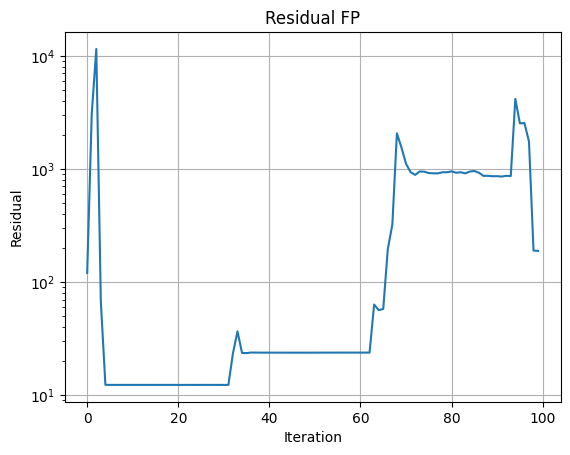

In [35]:
import matplotlib.pyplot as plt
plt.semilogy(residuals)
plt.title("Residual FP")
plt.xlabel("Iteration")
plt.ylabel("Residual")
plt.grid()

In [7]:
residuals

[119.99855024696416,
 579.7561887006163,
 13004.209207571423,
 3.307705117195468,
 2.5778745091273665,
 2.5993499847535424,
 2.609517223262129,
 3.777092576242423,
 4.0824135487383,
 3.653047876009884,
 3.2616696639031115,
 46.87099751848998,
 53.45890721661743,
 299.15378797709775,
 258.9266716975825,
 211.34209805982067,
 244.67369877298054,
 233.46907313584953,
 8.604100353937476,
 14.202600263007524,
 14.891608242526571,
 23.552993760284767,
 31.63353139543487,
 33.61539252474211,
 31.341380177883327,
 73.71301569571831,
 77.88945573624105,
 44.560963739952044,
 107.39733540624717,
 114.09367769354391,
 202.92732918639396,
 144.81792559887188,
 129.23943274455817,
 350.5842215291453,
 362.47860648947375,
 137.8465177263468,
 571.5968348204593,
 1322.6720057604732,
 881.766087464905,
 4737.102296251504,
 487.65606871417003,
 509.2690962108275,
 17354.589905178647,
 25704.648545887863,
 9249.123657842705,
 45944.638689847525,
 37475.27618930083,
 37334.09573937774,
 21291789.43274216

In [20]:
residuals

[8.53202237167752,
 9.06960710409739,
 432.7617552725995,
 942.8609769728406,
 194685.17857756634,
 787520.78912322,
 88358082.0536581,
 524551226.7139802,
 40443547067.572716,
 314104225480.0066,
 18661870378634.344,
 177228356470050.62,
 2.2067880825596428e+16,
 3.636756844597418e+32,
 4.9762056035213855e+64,
 9.182238094497603e+128,
 inf,
 nan]

# 1 Node

In [ ]:
path_data = os.path.abspath('')
path_data = path_data.rsplit('/', 1)[0]
path_data = os.path.join(path_data, 'gaslib', 'data')

network_names = ["GasLib-11", "GasLib-24", "GasLib-40", "GasLib-135", "GasLib-582", "GasLib-4197"]
# network_names = ["GasLib-11", "GasLib-24", "GasLib-40", "GasLib-135", "GasLib-582"]
# network_names = ["GasLib-11", "GasLib-24", "GasLib-40"]
# network_names = ["GasLib-582"]

final_error = []

# S = 0.589  # specific gravity of natural gas
# R = 8.314459848  # [J/molK]
# M = 28.97e-3  # [kg/mol] molar mass of air
# R_air = R / M  # [J/kgK]
# Z = 1  # compressibility factor
# pn = 101325  # [Pa] normal condition
# Tn = 273.15  # [K] normal condition
# T = Tn
# gas = Gas('natural gas', S, R_air, Z, pn, Tn, T)
# # rhon_g = gas.rhon

# S = 0.5537  # specific gravity of natural gas
# R = 8.314459848  # [J/molK]
# M = 28.97e-3  # [kg/mol] molar mass of air
# R_air = R / M  # [J/kgK]
# Z = 1  # compressibility factor
# pn = 101325  # [Pa] normal condition
# Tn = 293.15  # [K] normal condition
# T = Tn
# gas = Gas('natural gas', S, R_air, Z, pn, Tn, T)
# # rhon_g = gas.rhon

S = 0.0696 # This value to ensure equivalence between different pipe models
R = 8.314459848  # [J/molK]
M = 28.97e-3  # [kg/mol]
R_air = R/M  # [J/kgK]
Z = 1
pn = 101325 # [Pa]
Tn = 293.15 # [K]
T = Tn
gas = Gas('hydrogen gas', S, R_air, Z, pn, Tn, T)
# rhon_g = gas.rhon # [kg/m^3]

eta = 8/10
eta_ratio = 1/6
LHV = 33.33*3600*10**3 # [MJ/kg]
HHV = 1.418*10**8 # 60134305 # [MJ/kg]
unit_type = 'p2g'
unit_params = {'eta': eta,
               'eta_ratio': eta_ratio,
               'GHV': LHV}

for network_name in network_names:
    # create_networkx(path=path)
    gas_network, gas_node_data, gas_link_data = create_network_gaslib(os.path.join(path_data, network_name.lower(), network_name), gas=gas, q_inj_multiplier=1, no_slack=False)
    # elec_network, elec_data = create_network_pandapower(network_name='case4gs', no_slack=True)
    
    # per unit
    if gas.name in ["hydrogen", "hydrogen gas", "hydrogen_gas", \
                    "Hydrogen", "Hydrogen Gas", "Hydrogen_Gas", \
                    "h2", "H2"]:
        rho = gas.rhon
    else:
        rho = gas_node_data["normDensity_value"].max()
    qmax = convert_to_kg_per_second(value=gas_node_data["q_max_value"].max(), \
                                    rho=rho, \
                                    unit=gas_node_data["q_max_unit"][gas_node_data["q_max_value"].argmax()])
    qbase = qmax
    pbase = convert_to_pa(value=gas_node_data["pressureMax_value"].max(), \
                          unit=gas_node_data["pressureMax_unit"][gas_node_data["pressureMax_value"].argmax()])
    
    elec_network = ElectricalNetwork('1node')
    # e0 = ElectricalNode(name='e0', bc_type=0, V=1, delta=0) # Vdelta
    e0 = ElectricalNode(name='e0', bc_type=3, P=-100*MW, V=1, delta=0) # Vdelta
    elec_network.add_node(e0)
    
    # create integrated network
    het_network = HeterogeneousNetwork(network_name + ' + ' + '')

    # add single-carriers to integrated network
    het_network.add_network(gas_network)
    het_network.add_network(elec_network)
    
    c0 = HeterogeneousNode('p2g', x=0, y=0,
                           bc_type=1,
                           unit_type='p2g',
                           unit_params=unit_params)
    het_network.add_node(c0)

    # dummy links
    c0g0 = GasLink('c0g0', c0, gas_network.nodes[0])
    gas_network.add_link(c0g0)

    e0c0 = ElectricalLink('e0c0', elec_network.nodes[0], c0, bc_type=2, Qstart=0)
    elec_network.add_link(e0c0)
    
    formulation = {'gas': 'full',
                   'elec': 'complex_power',
                   'het': None}

    scale_var = 'per_unit'
    scale_var_params = {'qbase': qbase,
                        'pbase': pbase,
                        'Sbase': 100*MW,
                        'Vbase': 1,
                        'deltabase': 1,
                        'Ebase' : MW}
    
    # formulation = "full"
    # scale_var = "per_unit"
    # scale_var_params = {"qbase": qbase, 
    #                     "pbase": pbase}

    # start solving
    tol = 1e-6
    max_iter = 20
    solver = "NR"
    optimal_multiplier = False
    lin_solver = "gmres"
    lin_solver_parameters = {"block_size": (len(gas_network.links) + len(gas_network.nodes)) // 10,
                             "check_condition_number_p": False,
                             "check_eigenvalue_p": False,
                             "diag_pivot_thresh" : 0.1,
                             "drop_tol" : 1e-4,
                             "drop_rule" : ["basic", "area"],
                             "filename" : None,
                             "fill_factor": 1,
                             "max_iter": 100,
                             "nz_diag" : False,
                             "options" : {"Equil" : True},
                             "permc_spec": "colamd",
                             "preconditioner": "ilu",
                             "preconditioners_for_blocks": [],
                             "preconditioners_for_two_level": [],
                             "rcm" : False,
                             "residual": False,
                             "shift_value": 0,
                             "petsc_fill-in" : 5,
                             "petsc_gamgtype" : "classical",
                             "petsc_max_it": 100,
                             "petsc_nzdiag" : 0,
                             "petsc_nz_diag" : False,
                             "petsc_ord_type" : "qmd",
                             "petsc_preconditioner" : "ilu",
                             "petsc_reuse" : False,
                             "petsc_solver" : "gmres",
                             "petsc_zero_diagonal" : True}
    
    return_all_x = False
    check_condition_number = False
    check_determinant = False
    check_eigen = False
    check_eigenvalue = False
    check_J = False
    check_rank = False
    check_svd = False
    check_symmetric = False

    save_J = False

    # initial gas flow
    p_len = 0
    q_len = 0
    for element in het_network.get_x_entries(formulation=formulation)[1]:
        if isinstance(element, GasNode):
            p_len += 1
        elif isinstance(element, GasLink):
            q_len += 1
            
    q_init = 0.1 * qmax * np.ones(q_len)

    # initial pressure deviates from 5% to 10% of the reference pressure
    p_ref = convert_to_pa(value=gas_node_data["pressureMax_value"].max(), \
                          unit=gas_node_data["pressureMax_unit"][gas_node_data["pressureMax_value"].argmax()])
    p_init = p_ref * np.linspace(0.95, 0.9, p_len)

    # # update variables of class objects (nodes, links and terminal links)
    delta_init = np.zeros(len(het_network.get_x_entries(formulation=formulation)[3])) # flat start 0
    V_init = np.ones(len(het_network.get_x_entries(formulation=formulation)[4])) # flat start 1
    qc_init = np.ones(len(het_network.get_x_entries(formulation=formulation)[14])) # flat start 1
    Pc_init = np.ones(len(het_network.get_x_entries(formulation=formulation)[16])) # flat start 1

    het_network.initialize()
    het_network.update(np.concatenate([q_init, p_init, delta_init, V_init, qc_init, Pc_init]), formulation=formulation)

    x_sol, iterations, residuals, p_g_vec, q_vec, q_inj, \
    delta_vec, V_mag_vec, S_inj, P_edge, Q_edge, m_vec, \
    p_h_vec, Ts_vec, Tr_vec, m_hl_vec, phi_hl_vec, Ts_hl_vec, \
    Tr_hl_vec, qc_vec, Pc_vec, Qc_vec, mc_vec, phic_vec, \
    Tsc_vec, Trc_vec = het_network.solve_network(tol,
                                                 max_iter,
                                                 solver='NR',
                                                 formulation=formulation,
                                                 scale_var=scale_var,
                                                 scale_var_params=scale_var_params)
    
    # gas_network.update(np.concatenate([q_init, p_init]), formulation=formulation)
    # gas_network.initialize()

    # x_sol, iterations, residuals, p_g_vec, q_vec, q_inj = gas_network.solve_network(tol=tol,
    #                                                                                 max_iter=max_iter,
    #                                                                                 formulation=formulation,
    #                                                                                 scale_var=scale_var,
    #                                                                                 scale_var_params=scale_var_params,
    #                                                                                 solver=solver,
    #                                                                                 optimal_multiplier=optimal_multiplier,
    #                                                                                 lin_solver=lin_solver,
    #                                                                                 lin_solver_parameters=lin_solver_parameters,
    #                                                                                 return_all_x=return_all_x,
    #                                                                                 check_condition_number=check_condition_number,
    #                                                                                 check_determinant=check_determinant,
    #                                                                                 check_eigen=check_eigen,
    #                                                                                 check_eigenvalue=check_eigenvalue,
    #                                                                                 check_J=check_J,
    #                                                                                 check_rank=check_rank,
    #                                                                                 check_svd=check_svd,
    #                                                                                 check_symmetric=check_symmetric,
    #                                                                                 directory=None,
    #                                                                                 filename=lin_solver_parameters["filename"],
    #                                                                                 save_J=save_J)
        
    interim_data = "{:<18s} & {:<6s} & {:3d} & {:>.20f} \\\\ \\hline\n".format(network_name, str(residuals[-1] < tol), iterations, residuals[-1])
    print(interim_data, end="")
        
    # path = os.path.abspath('')
    # save_path = os.path.join(path, 'results', 'gaslib', 'no_coupling')
    # os.makedirs(save_path, exist_ok=True)
    # open(os.path.join(save_path, 'residual_nr.txt'), 'w').close()
    # f = open(os.path.join(save_path, 'residual_nr.txt'), 'a')
    # f.write(interim_data)
    # f.close()

    # path = os.path.abspath('')
    # save_path = os.path.join(path, 'results', 'gaslib', 'no_coupling', '{}'.format(network_name))
    # os.makedirs(save_path, exist_ok=True)

    # open(os.path.join(save_path, 'gas_pressure.txt'), 'w').close()
    # open(os.path.join(save_path, 'gas_injected_flow.txt'), 'w').close()
    # open(os.path.join(save_path, 'gas_flow.txt'), 'w').close()     
        
    # np.savetxt(os.path.join(save_path, 'residual_nr.txt'), residuals)      
    # np.savetxt(os.path.join(save_path, 'gas_pressure.txt'), p_g_vec)
    # np.savetxt(os.path.join(save_path, 'gas_injected_flow.txt'), q_inj)
    # np.savetxt(os.path.join(save_path, 'gas_flow.txt'), q_vec)

GasLib-11          & True   &   3 & 0.00000003287801820874 \\ \hline
GasLib-24          & True   &   3 & 0.00000000262433116666 \\ \hline
GasLib-40          & True   &   4 & 0.00000032271468546125 \\ \hline
GasLib-135         & True   &   8 & 0.00000001356634150577 \\ \hline
GasLib-582         & True   &  11 & 0.00000017678083363502 \\ \hline
GasLib-4197        & True   &  11 & 0.00000002260763118074 \\ \hline


# 1 Link

In [ ]:
path_data = os.path.abspath('')
path_data = path_data.rsplit('/', 1)[0]
path_data = os.path.join(path_data, 'gaslib', 'data')

network_names = ["GasLib-11", "GasLib-24", "GasLib-40", "GasLib-135", "GasLib-582", "GasLib-4197"]
# network_names = ["GasLib-11", "GasLib-24", "GasLib-40", "GasLib-135", "GasLib-582"]
# network_names = ["GasLib-11", "GasLib-24", "GasLib-40"]
# network_names = ["GasLib-582"]

final_error = []

# S = 0.589  # specific gravity of natural gas
# R = 8.314459848  # [J/molK]
# M = 28.97e-3  # [kg/mol] molar mass of air
# R_air = R / M  # [J/kgK]
# Z = 1  # compressibility factor
# pn = 101325  # [Pa] normal condition
# Tn = 273.15  # [K] normal condition
# T = Tn
# gas = Gas('natural gas', S, R_air, Z, pn, Tn, T)
# # rhon_g = gas.rhon

# S = 0.5537  # specific gravity of natural gas
# R = 8.314459848  # [J/molK]
# M = 28.97e-3  # [kg/mol] molar mass of air
# R_air = R / M  # [J/kgK]
# Z = 1  # compressibility factor
# pn = 101325  # [Pa] normal condition
# Tn = 293.15  # [K] normal condition
# T = Tn
# gas = Gas('natural gas', S, R_air, Z, pn, Tn, T)
# # rhon_g = gas.rhon

S = 0.0696 # This value to ensure equivalence between different pipe models
R = 8.314459848  # [J/molK]
M = 28.97e-3  # [kg/mol]
R_air = R/M  # [J/kgK]
Z = 1
pn = 101325 # [Pa]
Tn = 293.15 # [K]
T = Tn
gas = Gas('hydrogen gas', S, R_air, Z, pn, Tn, T)
# rhon_g = gas.rhon # [kg/m^3]

eta = 8/10
eta_ratio = 1/6
LHV = 33.33*3600*10**3 # [MJ/kg]
HHV = 1.418*10**8 # 60134305 # [MJ/kg]
unit_type = 'p2g'
unit_params = {'eta': eta,
               'eta_ratio': eta_ratio,
               'GHV': LHV / 100 / MW}

for network_name in network_names:
    # create_networkx(path=path)
    gas_network, gas_node_data, gas_link_data = create_network_gaslib(os.path.join(path_data, network_name.lower(), network_name), gas=gas, q_inj_multiplier=1, no_slack=False)
    # elec_network, elec_data = create_network_pandapower(network_name='case4gs', no_slack=True)
    
    # per unit
    if gas.name in ["hydrogen", "hydrogen gas", "hydrogen_gas", \
                    "Hydrogen", "Hydrogen Gas", "Hydrogen_Gas", \
                    "h2", "H2"]:
        rho = gas.rhon
    else:
        rho = gas_node_data["normDensity_value"].max()
    qmax = convert_to_kg_per_second(value=gas_node_data["q_max_value"].max(), \
                                    rho=rho, \
                                    unit=gas_node_data["q_max_unit"][gas_node_data["q_max_value"].argmax()])
    qbase = qmax
    pbase = convert_to_pa(value=gas_node_data["pressureMax_value"].max(), \
                          unit=gas_node_data["pressureMax_unit"][gas_node_data["pressureMax_value"].argmax()])
    
    elec_network = ElectricalNetwork('1node')
    # e0 = ElectricalNode(name='e0', bc_type=0, V=1, delta=0) # Vdelta
    e0 = ElectricalNode(name='e0', bc_type=2, P=0, Q=0) # PQ
    elec_network.add_node(e0)
    
    e1 = ElectricalNode(name='e1', bc_type=3, P=-1, V=1, delta=0) # PVdelta
    elec_network.add_node(e1)
    
    _, data_pp = create_network_pandapower(network_name='case4gs', no_slack=True)
    b, g, b_sh, g_sh = compute_admittance(c_nf_per_km=data_pp.line.loc[3, "c_nf_per_km"],
                                          f=data_pp.f_hz,
                                          g_us_per_km=data_pp.line.loc[3, "g_us_per_km"],
                                          length_km=data_pp.line.loc[3, "length_km"],
                                          parallel=data_pp.line.loc[3, "parallel"],
                                          r_ohm_per_km=data_pp.line.loc[3, "r_ohm_per_km"],
                                          x_ohm_per_km=data_pp.line.loc[3, "x_ohm_per_km"],
                                          Vn=230,
                                          Sn=100)
    
    elec_network.add_link(ElectricalLink(name="{}-{}".format(e0.name, e1.name),
                                         start_node=e1,
                                         end_node=e0,
                                         bc_type=0,
                                         link_type='pi_line',
                                         link_params={'b' : b,
                                                      'g' : g,
                                                      'b_sh' : b_sh,
                                                      'g_sh' : g_sh}))
    
    # create integrated network
    het_network = HeterogeneousNetwork(network_name + ' + ' + '')

    # add single-carriers to integrated network
    het_network.add_network(gas_network)
    het_network.add_network(elec_network)
    
    c0 = HeterogeneousNode('p2g', x=0, y=0,
                           bc_type=1,
                           unit_type='p2g',
                           unit_params=unit_params)
    het_network.add_node(c0)

    # dummy links
    c0g0 = GasLink('c0g0', c0, gas_network.nodes[0])
    gas_network.add_link(c0g0)

    e0c0 = ElectricalLink('e0c0', elec_network.nodes[0], c0, bc_type=2, Qstart=0)
    elec_network.add_link(e0c0)
    
    formulation = {'gas': 'full',
                   'elec': 'complex_power',
                   'het': None}

    scale_var = 'per_unit'
    scale_var_params = {'qbase': qbase,
                        'pbase': pbase,
                        'Sbase': 1,
                        'Vbase': 1,
                        'deltabase': 1,
                        'Ebase' : MW}
    
    # formulation = "full"
    # scale_var = "per_unit"
    # scale_var_params = {"qbase": qbase, 
    #                     "pbase": pbase}

    # start solving
    tol = 1e-6
    max_iter = 20
    solver = "NR"
    optimal_multiplier = False
    lin_solver = "direct"
    lin_solver_parameters = {"block_size": (len(gas_network.links) + len(gas_network.nodes)) // 10,
                             "check_condition_number_p": False,
                             "check_eigenvalue_p": False,
                             "diag_pivot_thresh" : 0.1,
                             "drop_tol" : 1e-4,
                             "drop_rule" : ["basic", "area"],
                             "filename" : None,
                             "fill_factor": 5,
                             "max_iter": 100,
                             "nz_diag" : False,
                             "options" : {"Equil" : True},
                             "permc_spec": "colamd",
                             "preconditioner": "ilu_constant",
                             "preconditioners_for_blocks": [],
                             "preconditioners_for_two_level": [],
                             "rcm" : False,
                             "residual": False,
                             "shift_value": 0,
                             "petsc_fill-in" : 5,
                             "petsc_gamgtype" : "classical",
                             "petsc_max_it": 100,
                             "petsc_nzdiag" : 0,
                             "petsc_nz_diag" : False,
                             "petsc_ord_type" : "qmd",
                             "petsc_preconditioner" : "ilu",
                             "petsc_reuse" : False,
                             "petsc_solver" : "gmres",
                             "petsc_zero_diagonal" : True}
    
    return_all_x = False
    check_condition_number = False
    check_determinant = False
    check_eigen = False
    check_eigenvalue = False
    check_J = False
    check_rank = False
    check_svd = False
    check_symmetric = False

    save_J = False

    # initial gas flow
    p_len = 0
    q_len = 0
    for element in het_network.get_x_entries(formulation=formulation)[1]:
        if isinstance(element, GasNode):
            p_len += 1
        elif isinstance(element, GasLink):
            q_len += 1
            
    q_init = 0.1 * qmax * np.ones(q_len)

    # initial pressure deviates from 5% to 10% of the reference pressure
    p_ref = convert_to_pa(value=gas_node_data["pressureMax_value"].max(), \
                          unit=gas_node_data["pressureMax_unit"][gas_node_data["pressureMax_value"].argmax()])
    p_init = p_ref * np.linspace(0.95, 0.9, p_len)

    # # update variables of class objects (nodes, links and terminal links)
    delta_init = np.zeros(len(het_network.get_x_entries(formulation=formulation)[3])) # flat start 0
    V_init = np.ones(len(het_network.get_x_entries(formulation=formulation)[4])) # flat start 1
    qc_init = np.ones(len(het_network.get_x_entries(formulation=formulation)[14])) # flat start 1
    Pc_init = np.ones(len(het_network.get_x_entries(formulation=formulation)[16])) # flat start 1

    het_network.initialize()
    het_network.update(np.concatenate([q_init, p_init, delta_init, V_init, qc_init, Pc_init]), formulation=formulation)

    x_sol, iterations, residuals, p_g_vec, q_vec, q_inj, \
    delta_vec, V_mag_vec, S_inj, P_edge, Q_edge, m_vec, \
    p_h_vec, Ts_vec, Tr_vec, m_hl_vec, phi_hl_vec, Ts_hl_vec, \
    Tr_hl_vec, qc_vec, Pc_vec, Qc_vec, mc_vec, phic_vec, \
    Tsc_vec, Trc_vec = het_network.solve_network(tol,
                                                 max_iter,
                                                 solver='NR',
                                                 formulation=formulation,
                                                 scale_var=scale_var,
                                                 scale_var_params=scale_var_params)
    
    # gas_network.update(np.concatenate([q_init, p_init]), formulation=formulation)
    # gas_network.initialize()

    # x_sol, iterations, residuals, p_g_vec, q_vec, q_inj = gas_network.solve_network(tol=tol,
    #                                                                                 max_iter=max_iter,
    #                                                                                 formulation=formulation,
    #                                                                                 scale_var=scale_var,
    #                                                                                 scale_var_params=scale_var_params,
    #                                                                                 solver=solver,
    #                                                                                 optimal_multiplier=optimal_multiplier,
    #                                                                                 lin_solver=lin_solver,
    #                                                                                 lin_solver_parameters=lin_solver_parameters,
    #                                                                                 return_all_x=return_all_x,
    #                                                                                 check_condition_number=check_condition_number,
    #                                                                                 check_determinant=check_determinant,
    #                                                                                 check_eigen=check_eigen,
    #                                                                                 check_eigenvalue=check_eigenvalue,
    #                                                                                 check_J=check_J,
    #                                                                                 check_rank=check_rank,
    #                                                                                 check_svd=check_svd,
    #                                                                                 check_symmetric=check_symmetric,
    #                                                                                 directory=None,
    #                                                                                 filename=lin_solver_parameters["filename"],
    #                                                                                 save_J=save_J)
        
    interim_data = "{:<18s} & {:<6s} & {:3d} & {:>.20f} \\\\ \\hline\n".format(network_name, str(residuals[-1] < tol), iterations, residuals[-1])
    print(interim_data, end="")
        
    # path = os.path.abspath('')
    # save_path = os.path.join(path, 'results', 'gaslib', 'no_coupling')
    # os.makedirs(save_path, exist_ok=True)
    # open(os.path.join(save_path, 'residual_nr.txt'), 'w').close()
    # f = open(os.path.join(save_path, 'residual_nr.txt'), 'a')
    # f.write(interim_data)
    # f.close()

    # path = os.path.abspath('')
    # save_path = os.path.join(path, 'results', 'gaslib', 'no_coupling', '{}'.format(network_name))
    # os.makedirs(save_path, exist_ok=True)

    # open(os.path.join(save_path, 'gas_pressure.txt'), 'w').close()
    # open(os.path.join(save_path, 'gas_injected_flow.txt'), 'w').close()
    # open(os.path.join(save_path, 'gas_flow.txt'), 'w').close()     
        
    # np.savetxt(os.path.join(save_path, 'residual_nr.txt'), residuals)      
    # np.savetxt(os.path.join(save_path, 'gas_pressure.txt'), p_g_vec)
    # np.savetxt(os.path.join(save_path, 'gas_injected_flow.txt'), q_inj)
    # np.savetxt(os.path.join(save_path, 'gas_flow.txt'), q_vec)

GasLib-11          & True   &   3 & 0.00000003287981565338 \\ \hline
GasLib-24          & True   &   3 & 0.00000000263906298701 \\ \hline
GasLib-40          & True   &   4 & 0.00000032271470645894 \\ \hline
GasLib-135         & True   &   8 & 0.00000001356634150577 \\ \hline
GasLib-582         & True   &  11 & 0.00000017678083363502 \\ \hline
GasLib-4197        & True   &  11 & 0.00000002260763118074 \\ \hline


In [189]:
elec_node_count = 0
delta_node = len(het_network.get_x_entries(formulation=formulation)[3])

for el, value in zip(het_network.get_x_entries(formulation)[0], x_sol):
    if isinstance(el, GasNode):
        print('{:>25s} {:>3s} = {}'.format(el.name, '(p)', value))
    elif isinstance(el, GasLink):
        print('{:>25s} {:>3s} = {}'.format(el.name, '(q)', value))
    elif isinstance(el, ElectricalNode):
        if elec_node_count < delta_node:
            print('{:>25s} {:>3s} = {}'.format(el.name, '(d)', value))
            elec_node_count += 1
        else:
            print('{:>25s} {:>3s} = {}'.format(el.name, '(V)', value))
    elif isinstance(el, ElectricalLink):
        print('{:>25s} {:>3s} = {}'.format(el.name, '(P)', value))

                   pipe_1 (q) = -0.01405888132375236
                   pipe_2 (q) = 0.0
                   pipe_3 (q) = -0.006986547003435082
                   pipe_4 (q) = -0.014178705877589935
                   pipe_5 (q) = 0.0
                   pipe_6 (q) = 0.014178705877589935
                   pipe_7 (q) = 0.007192158874154852
                   pipe_8 (q) = 0.012248143181571787
                   pipe_9 (q) = 0.014178705877589935
                  pipe_10 (q) = 0.04703602347195761
                  pipe_11 (q) = 0.0
                  pipe_12 (q) = 0.0
                  pipe_13 (q) = -0.014178705877589935
                  pipe_14 (q) = -0.014178705877589935
                  pipe_15 (q) = 0.0
                  pipe_16 (q) = -0.014178705877589935
                  pipe_17 (q) = -0.0019305626960181479
                  pipe_18 (q) = -0.014178705877589935
                  pipe_19 (q) = -0.014178705877589935
                  pipe_20 (q) = -0.010484623038710186
                

In [ ]:
path_data = os.path.abspath('')
path_data = path_data.rsplit('/', 1)[0]
path_data = os.path.join(path_data, 'gaslib', 'data')

network_names = ["GasLib-11", "GasLib-24", "GasLib-40", "GasLib-135", "GasLib-582", "GasLib-4197"]
# network_names = ["GasLib-11", "GasLib-24", "GasLib-40", "GasLib-135", "GasLib-582"]
# network_names = ["GasLib-11", "GasLib-24", "GasLib-40"]
# network_names = ["GasLib-582"]

final_error = []

# S = 0.589  # specific gravity of natural gas
# R = 8.314459848  # [J/molK]
# M = 28.97e-3  # [kg/mol] molar mass of air
# R_air = R / M  # [J/kgK]
# Z = 1  # compressibility factor
# pn = 101325  # [Pa] normal condition
# Tn = 273.15  # [K] normal condition
# T = Tn
# gas = Gas('natural gas', S, R_air, Z, pn, Tn, T)
# # rhon_g = gas.rhon

# S = 0.5537  # specific gravity of natural gas
# R = 8.314459848  # [J/molK]
# M = 28.97e-3  # [kg/mol] molar mass of air
# R_air = R / M  # [J/kgK]
# Z = 1  # compressibility factor
# pn = 101325  # [Pa] normal condition
# Tn = 293.15  # [K] normal condition
# T = Tn
# gas = Gas('natural gas', S, R_air, Z, pn, Tn, T)
# # rhon_g = gas.rhon

S = 0.0696 # This value to ensure equivalence between different pipe models
R = 8.314459848  # [J/molK]
M = 28.97e-3  # [kg/mol]
R_air = R/M  # [J/kgK]
Z = 1
pn = 101325 # [Pa]
Tn = 293.15 # [K]
T = Tn
gas = Gas('hydrogen gas', S, R_air, Z, pn, Tn, T)
# rhon_g = gas.rhon # [kg/m^3]

eta = 8/10
eta_ratio = 1/6
LHV = 33.33*3600*10**3 # [MJ/kg]
HHV = 1.418*10**8 # 60134305 # [MJ/kg]
unit_type = 'p2g'
unit_params = {'eta': eta,
               'eta_ratio': eta_ratio,
               'GHV': LHV / 100 / MW}

for network_name in network_names:
    # create_networkx(path=path)
    gas_network, gas_node_data, gas_link_data = create_network_gaslib(os.path.join(path_data, network_name.lower(), network_name), gas=gas, q_inj_multiplier=1, no_slack=False)
    elec_network, elec_data = create_network_pandapower(network_name='case9241pegase', no_slack=True)
    
    # per unit
    if gas.name in ["hydrogen", "hydrogen gas", "hydrogen_gas", \
                    "Hydrogen", "Hydrogen Gas", "Hydrogen_Gas", \
                    "h2", "H2"]:
        rho = gas.rhon
    else:
        rho = gas_node_data["normDensity_value"].max()
    qmax = convert_to_kg_per_second(value=gas_node_data["q_max_value"].max(), \
                                    rho=rho, \
                                    unit=gas_node_data["q_max_unit"][gas_node_data["q_max_value"].argmax()])
    qbase = qmax
    pbase = convert_to_pa(value=gas_node_data["pressureMax_value"].max(), \
                          unit=gas_node_data["pressureMax_unit"][gas_node_data["pressureMax_value"].argmax()])
        
    # create integrated network
    het_network = HeterogeneousNetwork(network_name + ' + ' + '')

    # add single-carriers to integrated network
    het_network.add_network(gas_network)
    het_network.add_network(elec_network)
    
    c0 = HeterogeneousNode('p2g', x=0, y=0,
                           bc_type=1,
                           unit_type='p2g',
                           unit_params=unit_params)
    het_network.add_node(c0)

    # dummy links
    c0g0 = GasLink('c0g0', c0, gas_network.nodes[0])
    gas_network.add_link(c0g0)

    e0c0 = ElectricalLink('e0c0', elec_network.nodes[0], c0, bc_type=2, Qstart=0)
    elec_network.add_link(e0c0)
    
    formulation = {'gas': 'full',
                   'elec': 'complex_power',
                   'het': None}

    scale_var = 'per_unit'
    scale_var_params = {'qbase': qbase,
                        'pbase': pbase,
                        'Sbase': 1,
                        'Vbase': 1,
                        'deltabase': 1,
                        'Ebase' : MW}
    
    # formulation = "full"
    # scale_var = "per_unit"
    # scale_var_params = {"qbase": qbase, 
    #                     "pbase": pbase}

    # start solving
    tol = 1e-6
    max_iter = 20
    solver = "NR"
    optimal_multiplier = False
    lin_solver = "direct"
    lin_solver_parameters = {"block_size": (len(gas_network.links) + len(gas_network.nodes)) // 10,
                             "check_condition_number_p": False,
                             "check_eigenvalue_p": False,
                             "diag_pivot_thresh" : 0.1,
                             "drop_tol" : 1e-4,
                             "drop_rule" : ["basic", "area"],
                             "filename" : None,
                             "fill_factor": 5,
                             "max_iter": 100,
                             "nz_diag" : False,
                             "options" : {"Equil" : True},
                             "permc_spec": "colamd",
                             "preconditioner": "ilu_constant",
                             "preconditioners_for_blocks": [],
                             "preconditioners_for_two_level": [],
                             "rcm" : False,
                             "residual": False,
                             "shift_value": 0,
                             "petsc_fill-in" : 5,
                             "petsc_gamgtype" : "classical",
                             "petsc_max_it": 100,
                             "petsc_nzdiag" : 0,
                             "petsc_nz_diag" : False,
                             "petsc_ord_type" : "qmd",
                             "petsc_preconditioner" : "ilu",
                             "petsc_reuse" : False,
                             "petsc_solver" : "gmres",
                             "petsc_zero_diagonal" : True}
    
    return_all_x = False
    check_condition_number = False
    check_determinant = False
    check_eigen = False
    check_eigenvalue = False
    check_J = False
    check_rank = False
    check_svd = False
    check_symmetric = False

    save_J = False

    # initial gas flow
    p_len = 0
    q_len = 0
    for element in het_network.get_x_entries(formulation=formulation)[1]:
        if isinstance(element, GasNode):
            p_len += 1
        elif isinstance(element, GasLink):
            q_len += 1
            
    q_init = 0.1 * qmax * np.ones(q_len)

    # initial pressure deviates from 5% to 10% of the reference pressure
    p_ref = convert_to_pa(value=gas_node_data["pressureMax_value"].max(), \
                          unit=gas_node_data["pressureMax_unit"][gas_node_data["pressureMax_value"].argmax()])
    p_init = p_ref * np.linspace(0.95, 0.9, p_len)

    # # update variables of class objects (nodes, links and terminal links)
    delta_init = np.zeros(len(het_network.get_x_entries(formulation=formulation)[3])) # flat start 0
    V_init = np.ones(len(het_network.get_x_entries(formulation=formulation)[4])) # flat start 1
    qc_init = np.ones(len(het_network.get_x_entries(formulation=formulation)[14])) # flat start 1
    Pc_init = np.ones(len(het_network.get_x_entries(formulation=formulation)[16])) # flat start 1

    het_network.initialize()
    het_network.update(np.concatenate([q_init, p_init, delta_init, V_init, qc_init, Pc_init]), formulation=formulation)

    x_sol, iterations, residuals, p_g_vec, q_vec, q_inj, \
    delta_vec, V_mag_vec, S_inj, P_edge, Q_edge, m_vec, \
    p_h_vec, Ts_vec, Tr_vec, m_hl_vec, phi_hl_vec, Ts_hl_vec, \
    Tr_hl_vec, qc_vec, Pc_vec, Qc_vec, mc_vec, phic_vec, \
    Tsc_vec, Trc_vec = het_network.solve_network(tol,
                                                 max_iter,
                                                 solver='NR',
                                                 formulation=formulation,
                                                 scale_var=scale_var,
                                                 scale_var_params=scale_var_params)
    
    # gas_network.update(np.concatenate([q_init, p_init]), formulation=formulation)
    # gas_network.initialize()

    # x_sol, iterations, residuals, p_g_vec, q_vec, q_inj = gas_network.solve_network(tol=tol,
    #                                                                                 max_iter=max_iter,
    #                                                                                 formulation=formulation,
    #                                                                                 scale_var=scale_var,
    #                                                                                 scale_var_params=scale_var_params,
    #                                                                                 solver=solver,
    #                                                                                 optimal_multiplier=optimal_multiplier,
    #                                                                                 lin_solver=lin_solver,
    #                                                                                 lin_solver_parameters=lin_solver_parameters,
    #                                                                                 return_all_x=return_all_x,
    #                                                                                 check_condition_number=check_condition_number,
    #                                                                                 check_determinant=check_determinant,
    #                                                                                 check_eigen=check_eigen,
    #                                                                                 check_eigenvalue=check_eigenvalue,
    #                                                                                 check_J=check_J,
    #                                                                                 check_rank=check_rank,
    #                                                                                 check_svd=check_svd,
    #                                                                                 check_symmetric=check_symmetric,
    #                                                                                 directory=None,
    #                                                                                 filename=lin_solver_parameters["filename"],
    #                                                                                 save_J=save_J)
        
    interim_data = "{:<18s} & {:<6s} & {:3d} & {:>.20f} \\\\ \\hline\n".format(network_name, str(residuals[-1] < tol), iterations, residuals[-1])
    print(interim_data, end="")
        
    # path = os.path.abspath('')
    # save_path = os.path.join(path, 'results', 'gaslib', 'no_coupling')
    # os.makedirs(save_path, exist_ok=True)
    # open(os.path.join(save_path, 'residual_nr.txt'), 'w').close()
    # f = open(os.path.join(save_path, 'residual_nr.txt'), 'a')
    # f.write(interim_data)
    # f.close()

    # path = os.path.abspath('')
    # save_path = os.path.join(path, 'results', 'gaslib', 'no_coupling', '{}'.format(network_name))
    # os.makedirs(save_path, exist_ok=True)

    # open(os.path.join(save_path, 'gas_pressure.txt'), 'w').close()
    # open(os.path.join(save_path, 'gas_injected_flow.txt'), 'w').close()
    # open(os.path.join(save_path, 'gas_flow.txt'), 'w').close()     
        
    # np.savetxt(os.path.join(save_path, 'residual_nr.txt'), residuals)      
    # np.savetxt(os.path.join(save_path, 'gas_pressure.txt'), p_g_vec)
    # np.savetxt(os.path.join(save_path, 'gas_injected_flow.txt'), q_inj)
    # np.savetxt(os.path.join(save_path, 'gas_flow.txt'), q_vec)

GasLib-11          & True   &   6 & 0.00000000002728653726 \\ \hline
GasLib-24          & True   &   6 & 0.00000000372538017621 \\ \hline
GasLib-40          & True   &   6 & 0.00000000002660932013 \\ \hline
GasLib-135         & True   &   8 & 0.00000001406854705217 \\ \hline
GasLib-582         & True   &  11 & 0.00000017693777119363 \\ \hline
GasLib-4197        & True   &  11 & 0.00000002260764447527 \\ \hline


In [17]:
get_data('case9241pegase').trafo.keys()

Index(['name', 'std_type', 'hv_bus', 'lv_bus', 'sn_mva', 'vn_hv_kv',
       'vn_lv_kv', 'vk_percent', 'vkr_percent', 'pfe_kw', 'i0_percent',
       'shift_degree', 'tap_side', 'tap_neutral', 'tap_min', 'tap_max',
       'tap_step_percent', 'tap_step_degree', 'tap_pos', 'parallel', 'df',
       'in_service', 'max_loading_percent', 'tap_changer_type'],
      dtype='object')

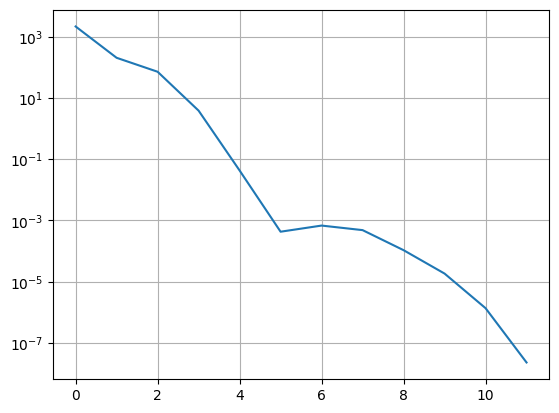

In [191]:
import matplotlib.pyplot as plt
plt.semilogy(residuals)
plt.grid()

In [ ]:
path_data = os.path.abspath('')
path_data = path_data.rsplit('/', 1)[0]
path_data = os.path.join(path_data, 'gaslib', 'data')

network_names = ["GasLib-11", "GasLib-24", "GasLib-40", "GasLib-135", "GasLib-582", "GasLib-4197"]
# network_names = ["GasLib-11", "GasLib-24", "GasLib-40", "GasLib-135", "GasLib-582"]
# network_names = ["GasLib-11", "GasLib-24", "GasLib-40"]
# network_names = ["GasLib-582"]

final_error = []

# S = 0.589  # specific gravity of natural gas
# R = 8.314459848  # [J/molK]
# M = 28.97e-3  # [kg/mol] molar mass of air
# R_air = R / M  # [J/kgK]
# Z = 1  # compressibility factor
# pn = 101325  # [Pa] normal condition
# Tn = 273.15  # [K] normal condition
# T = Tn
# gas = Gas('natural gas', S, R_air, Z, pn, Tn, T)
# # rhon_g = gas.rhon

# S = 0.5537  # specific gravity of natural gas
# R = 8.314459848  # [J/molK]
# M = 28.97e-3  # [kg/mol] molar mass of air
# R_air = R / M  # [J/kgK]
# Z = 1  # compressibility factor
# pn = 101325  # [Pa] normal condition
# Tn = 293.15  # [K] normal condition
# T = Tn
# gas = Gas('natural gas', S, R_air, Z, pn, Tn, T)
# # rhon_g = gas.rhon

S = 0.0696 # This value to ensure equivalence between different pipe models
R = 8.314459848  # [J/molK]
M = 28.97e-3  # [kg/mol]
R_air = R/M  # [J/kgK]
Z = 1
pn = 101325 # [Pa]
Tn = 293.15 # [K]
T = Tn
gas = Gas('hydrogen gas', S, R_air, Z, pn, Tn, T)
# rhon_g = gas.rhon # [kg/m^3]

eta = 8/10
eta_ratio = 1/6
LHV = 33.33*3600*10**3 # [MJ/kg]
HHV = 1.418*10**8 # 60134305 # [MJ/kg]
unit_type = 'p2g'
unit_params = {'eta': eta,
               'eta_ratio': eta_ratio,
               'GHV': LHV / 100 / MW}

elec_network_name = 'case9241pegase' # 'case4gs'

for case_number, network_name in enumerate(network_names):
    # create_networkx(path=path)
    gas_network, gas_node_data, gas_link_data = create_network_gaslib(os.path.join(path_data, network_name.lower(), network_name), gas=gas, q_inj_multiplier=1, no_slack=False)
    elec_network, elec_data = create_network_pandapower(network_name=elec_network_name, no_slack=True)
    
    # per unit
    if gas.name in ["hydrogen", "hydrogen gas", "hydrogen_gas", \
                    "Hydrogen", "Hydrogen Gas", "Hydrogen_Gas", \
                    "h2", "H2"]:
        rho = gas.rhon
    else:
        rho = gas_node_data["normDensity_value"].max()
    qmax = convert_to_kg_per_second(value=gas_node_data["q_max_value"].max(), \
                                    rho=rho, \
                                    unit=gas_node_data["q_max_unit"][gas_node_data["q_max_value"].argmax()])
    qbase = qmax
    pbase = convert_to_pa(value=gas_node_data["pressureMax_value"].max(), \
                          unit=gas_node_data["pressureMax_unit"][gas_node_data["pressureMax_value"].argmax()])
        
    # create integrated network
    het_network = HeterogeneousNetwork(network_name + ' + ' + '')

    # add single-carriers to integrated network
    het_network.add_network(gas_network)
    het_network.add_network(elec_network)
    
    c0 = HeterogeneousNode('p2g', x=0, y=0,
                           bc_type=1,
                           unit_type='p2g',
                           unit_params=unit_params)
    het_network.add_node(c0)

    # dummy links
    c0g0 = GasLink('c0g0', c0, gas_network.nodes[0])
    gas_network.add_link(c0g0)

    e0c0 = ElectricalLink('e0c0', elec_network.nodes[0], c0, bc_type=2, Qstart=0)
    elec_network.add_link(e0c0)
    
    formulation = {'gas': 'full',
                   'elec': 'complex_power',
                   'het': None}

    scale_var = 'per_unit'
    scale_var_params = {'qbase': qbase,
                        'pbase': pbase,
                        'Sbase': 1,
                        'Vbase': 1,
                        'deltabase': 1,
                        'Ebase' : MW}
    
    # formulation = "full"
    # scale_var = "per_unit"
    # scale_var_params = {"qbase": qbase, 
    #                     "pbase": pbase}

    # start solving
    tol = 1e-6
    max_iter = 20
    solver = "NR"
    optimal_multiplier = False
    lin_solver = "gmres"
    lin_solver_parameters = {"block_size": (len(gas_network.links) + len(gas_network.nodes)) // 10,
                             "check_condition_number_p": False,
                             "check_eigenvalue_p": False,
                             "diag_pivot_thresh" : 0.1,
                             "drop_tol" : 1e-4,
                             "drop_rule" : ["basic", "area"],
                             "filename" : None,
                             "fill_factor": 5,
                             "max_iter": 100,
                             "nz_diag" : False,
                             "options" : {"Equil" : True},
                             "permc_spec": "colamd",
                             "preconditioner": "ilu",
                             "preconditioners_for_blocks": [],
                             "preconditioners_for_two_level": [],
                             "rcm" : False,
                             "residual": False,
                             "shift_value": 0,
                             "tol" : 1e-6,
                             "petsc_fill-in" : 5,
                             "petsc_gamgtype" : "classical",
                             "petsc_max_it": 100,
                             "petsc_nzdiag" : 0,
                             "petsc_nz_diag" : False,
                             "petsc_ord_type" : "qmd",
                             "petsc_preconditioner" : "ilu",
                             "petsc_reuse" : False,
                             "petsc_solver" : "gmres",
                             "petsc_zero_diagonal" : True}
    
    return_all_x = False
    check_condition_number = False
    check_determinant = False
    check_eigen = False
    check_eigenvalue = False
    check_J = False
    check_rank = False
    check_svd = False
    check_symmetric = False

    save_J = False

    # initial gas flow
    p_len = 0
    q_len = 0
    for element in het_network.get_x_entries(formulation=formulation)[1]:
        if isinstance(element, GasNode):
            p_len += 1
        elif isinstance(element, GasLink):
            q_len += 1
            
    q_init = 0.1 * qmax * np.ones(q_len)

    # initial pressure deviates from 5% to 10% of the reference pressure
    p_ref = convert_to_pa(value=gas_node_data["pressureMax_value"].max(), \
                          unit=gas_node_data["pressureMax_unit"][gas_node_data["pressureMax_value"].argmax()])
    p_init = p_ref * np.linspace(0.95, 0.9, p_len)

    # # update variables of class objects (nodes, links and terminal links)
    delta_init = np.zeros(len(het_network.get_x_entries(formulation=formulation)[3])) # flat start 0
    V_init = np.ones(len(het_network.get_x_entries(formulation=formulation)[4])) # flat start 1
    qc_init = np.ones(len(het_network.get_x_entries(formulation=formulation)[14])) # flat start 1
    Pc_init = np.ones(len(het_network.get_x_entries(formulation=formulation)[16])) # flat start 1

    het_network.initialize()
    het_network.update(np.concatenate([q_init, p_init, delta_init, V_init, qc_init, Pc_init]), formulation=formulation)

    path = os.path.abspath('')
    save_path = os.path.join(path, 'results', 'combined', 'supply', \
                             lin_solver, lin_solver_parameters["preconditioner"], str(lin_solver_parameters["fill_factor"]), \
                             '{}_{}'.format(network_name, elec_network_name))
    os.makedirs(save_path, exist_ok=True)
    
    lin_solver_parameters["filename"] = os.path.join(save_path, 'residual.txt')

    x_sol, iterations, residuals, p_g_vec, q_vec, q_inj, \
    delta_vec, V_mag_vec, S_inj, P_edge, Q_edge, m_vec, \
    p_h_vec, Ts_vec, Tr_vec, m_hl_vec, phi_hl_vec, Ts_hl_vec, \
    Tr_hl_vec, qc_vec, Pc_vec, Qc_vec, mc_vec, phic_vec, \
    Tsc_vec, Trc_vec = het_network.solve_network(tol=tol,
                                                 max_iter=max_iter,
                                                 formulation=formulation,
                                                 scale_var=scale_var,
                                                 scale_var_params=scale_var_params,
                                                 solver=solver,
                                                 optimal_multiplier=optimal_multiplier,
                                                 lin_solver=lin_solver,
                                                 lin_solver_parameters=lin_solver_parameters,
                                                 return_all_x=return_all_x,)
    
    # gas_network.update(np.concatenate([q_init, p_init]), formulation=formulation)
    # gas_network.initialize()

    # x_sol, iterations, residuals, p_g_vec, q_vec, q_inj = gas_network.solve_network(tol=tol,
    #                                                                                 max_iter=max_iter,
    #                                                                                 formulation=formulation,
    #                                                                                 scale_var=scale_var,
    #                                                                                 scale_var_params=scale_var_params,
    #                                                                                 solver=solver,
    #                                                                                 optimal_multiplier=optimal_multiplier,
    #                                                                                 lin_solver=lin_solver,
    #                                                                                 lin_solver_parameters=lin_solver_parameters,
    #                                                                                 return_all_x=return_all_x,
    #                                                                                 check_condition_number=check_condition_number,
    #                                                                                 check_determinant=check_determinant,
    #                                                                                 check_eigen=check_eigen,
    #                                                                                 check_eigenvalue=check_eigenvalue,
    #                                                                                 check_J=check_J,
    #                                                                                 check_rank=check_rank,
    #                                                                                 check_svd=check_svd,
    #                                                                                 check_symmetric=check_symmetric,
    #                                                                                 directory=None,
    #                                                                                 filename=lin_solver_parameters["filename"],
    #                                                                                 save_J=save_J)
        
    interim_data = "{:<18s} & {:<6s} & {:3d} & {:>.20f} \\\\ \\hline\n".format(network_name, str(residuals[-1] < tol), iterations, residuals[-1])
    print(interim_data, end="")
           
    path = os.path.abspath('')
    save_path = os.path.join(path, 'results', 'combined', 'supply', \
                             lin_solver, lin_solver_parameters["preconditioner"], str(lin_solver_parameters["fill_factor"]))
    os.makedirs(save_path, exist_ok=True)           
 
    if case_number == 0:
        open(os.path.join(save_path, 'residual_nr_{}_{}.txt'.format('GasLib', elec_network_name)), 'w').close()
        
    f = open(os.path.join(save_path, 'residual_nr_{}_{}.txt'.format('GasLib', elec_network_name)), 'a')
    f.write(interim_data)
    f.close()
    
    path = os.path.abspath('')
    save_path = os.path.join(path, 'results', 'combined', 'supply', \
                             lin_solver, lin_solver_parameters["preconditioner"], str(lin_solver_parameters["fill_factor"]), \
                             '{}_{}'.format(network_name, elec_network_name))
    os.makedirs(save_path, exist_ok=True)

    open(os.path.join(save_path, 'gas_pressure.txt'), 'w').close()
    open(os.path.join(save_path, 'gas_injected_flow.txt'), 'w').close()
    open(os.path.join(save_path, 'gas_flow.txt'), 'w').close()
    open(os.path.join(save_path, 'delta.txt'), 'w').close()
    open(os.path.join(save_path, 'voltage.txt'), 'w').close()
    open(os.path.join(save_path, 'injected_complex_power.txt'), 'w').close()
    open(os.path.join(save_path, 'active_power.txt'), 'w').close()
    open(os.path.join(save_path, 'reactive_power.txt'), 'w').close()
    open(os.path.join(save_path, 'coupling_gas_flow.txt'), 'w').close()
    open(os.path.join(save_path, 'coupling_active_power.txt'), 'w').close()
    open(os.path.join(save_path, 'coupling_reactive_power.txt'), 'w').close()
    open(os.path.join(save_path, 'residual_nr.txt'), 'w').close()
                
    np.savetxt(os.path.join(save_path, 'gas_pressure.txt'), p_g_vec)
    np.savetxt(os.path.join(save_path, 'gas_injected_flow.txt'), q_inj)
    np.savetxt(os.path.join(save_path, 'gas_flow.txt'), q_vec)
    np.savetxt(os.path.join(save_path, 'delta.txt'), delta_vec)
    np.savetxt(os.path.join(save_path, 'voltage.txt'), V_mag_vec)
    np.savetxt(os.path.join(save_path, 'injected_complex_power.txt'), S_inj)
    np.savetxt(os.path.join(save_path, 'active_power.txt'), P_edge)
    np.savetxt(os.path.join(save_path, 'reactive_power.txt'), Q_edge)
    np.savetxt(os.path.join(save_path, 'coupling_gas_flow.txt'), qc_vec)
    np.savetxt(os.path.join(save_path, 'coupling_active_power.txt'), Pc_vec)
    np.savetxt(os.path.join(save_path, 'coupling_reactive_power.txt'), Qc_vec)
    
    np.savetxt(os.path.join(save_path, 'residual_nr.txt'), residuals)
    np.savetxt(os.path.join(save_path, 'l_time.txt'), het_network.l_time)
    np.savetxt(os.path.join(save_path, 'nl_time.txt'), het_network.nl_time)
    np.savetxt(os.path.join(save_path, 'F_time.txt'), het_network.F_time)
    np.savetxt(os.path.join(save_path, 'J_time.txt'), het_network.J_time)

GasLib-11          & True   &   6 & 0.00000000002880983158 \\ \hline
GasLib-24          & True   &   6 & 0.00000000002739243396 \\ \hline
GasLib-40          & True   &   6 & 0.00000000002733453889 \\ \hline
GasLib-135         & True   &   8 & 0.00000001356631939847 \\ \hline
GasLib-582         & True   &  11 & 0.00000017678058773879 \\ \hline
GasLib-4197        & True   &  11 & 0.00000002260791138449 \\ \hline


In [23]:
l = ['flow', 'resistor', 'high', 'low']

count = 0
for i in range(2):
    print("ok")
    for j in l:
        count += 1
        if 'high' in j:
            print("{}".format(count))
            break

ok
3
ok
6
